# Overview

**Objective**: Establish a baseline hybrid modeling pipeline, combining Linear Regression and XGBoost for robust sales forecasting.

This study applies a hybrid approach to the Rossmann dataset. Linear Regression acts as the base model to capture macroscopic linear relationships between predictors and the target variable. Subsequently, the residuals from the linear model are fed into an XGBoost architecture to model complex non-linear patterns.

The study further evaluates logarithmic transformation's impact on stabilizing variance and reducing outlier sensitivity in highly skewed retail sales data.


# Reference-Based Exploration

Exploration defines the core Study 6 methodology. Preprocessing includes multivariate feature engineering, a chronological train/test split, and logarithmic target transformation. Evaluated models include standalone XGBoost, XGBoost with log-transformed targets, and the proposed Linear Regression + XGBoost Hybrid with residual correction.


## Preprocessing

Data loading, exploratory analysis (EDA), feature engineering, and data cleaning define the Study 6 pipeline. Operations include null handling, Promo2 feature generation, one-hot encoding, and feature pruning.


### Library Imports

Import required data processing and modeling libraries.


In [21]:
import sys, os
project_root = os.path.abspath(os.path.join(os.getcwd(), "../.."))
sys.path.append(project_root)

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import optuna
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import GridSearchCV
from src.utils.geo import GEO
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, RobustScaler
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
import joblib
from xgboost import XGBRegressor
from src.utils.loss import rmspe_sklearn
from src.utils.save import save_model, save_features
import warnings
warnings.filterwarnings('ignore')
from src.models.grnn import GRNN
import optuna

optuna.logging.set_verbosity(optuna.logging.ERROR)

In [23]:
def rmspe(y_true, y_pred):
    return np.sqrt(np.mean(((y_true - y_pred) / y_true) ** 2))

distances = ["euclidean"]
# distances = ["euclidean", "manhattan", "chebyshev", "minkowski", "hamming", "mahalanobis"]

### Data Loading

Load the Rossmann training and store metadata datasets.


In [33]:
train = pd.read_csv('../data/raw/rossmann/train.csv', low_memory=False)
store = pd.read_csv('../data/raw/rossmann/store.csv', low_memory=False)
test = pd.read_csv('../data/raw/rossmann/test.csv', low_memory=False)
data = pd.merge(train, store, how='left', on='Store')
data['Date'] = pd.to_datetime(data['Date'], errors='coerce')
series = data.sort_values('Date')
series.shape

(1017209, 18)

### EDA

Exploratory Data Analysis prioritizing null distributions and feature correlations.


#### 1 Data Understanding

Evaluate fundamental data attributes and missing values.


##### 1.1 Data Null

Analyze columns containing null values.

**Null Value Handling Strategy**
- `Promo2SinceWeek`, `Promo2SinceYear`, and `PromoInterval` exhibit null values strictly for stores non-participant in the Promo2 program (`Promo2 = 0`).
- Feature engineering consolidates these into a unified `IsPromo2Active` flag, rendering the raw historical promo columns redundant for modeling.


In [9]:
# pd.DataFrame(series.isna().sum()).T
series.isna().sum()

Store                             0
DayOfWeek                         0
Date                              0
Sales                             0
Customers                         0
Open                              0
Promo                             0
StateHoliday                      0
SchoolHoliday                     0
StoreType                         0
Assortment                        0
CompetitionDistance            2642
CompetitionOpenSinceMonth    323348
CompetitionOpenSinceYear     323348
Promo2                            0
Promo2SinceWeek              508031
Promo2SinceYear              508031
PromoInterval                508031
dtype: int64

Based on the analysis above, here are the interpretation details.
1. CompetitionDistance has 2,642 null values
2. CompetitionOpenSinceMonth has 323,348 null values
3. CompetitionOpenSinceYear has 323,348 null values
4. Promo2SinceWeek has 508,031 null values
5. Promo2SinceYear has 508,031 null values
6. PromoInterval has 508,031 null values

**Null Value Handling Strategy**
Based on the analysis and understanding of the data context:
- Columns Promo2SinceWeek, Promo2SinceYear, and PromoInterval have null values for stores not participating in the Promo2 program (Promo2 = 0).
- Since the cross-check in section **2.1.2.2** already performed feature engineering by creating the new variable IsPromo2Active — which represents the active promotion state based on Promo2 and PromoInterval — these three columns are considered redundant and no longer needed at the modeling stage.

##### 1.2 Promo, Promo2, PromoInterval, Promo2SinceWeek, Promo2SinceYear

Investigate relationships between promotional features and the target `Sales`.

**Exploration Objectives:**
1. Comprehend the operational mechanics of Promo2 scheduling.
2. Cross-check active promotion alignment with `PromoInterval` constraints.


###### 1.2.1 Store has join promo2

Analyze a localized subset of stores actively participating in Promo2.

**Visual Summary:**

| Feature                               | Level         | Practical Meaning                          |
| ------------------------------------- | ------------- | ------------------------------------------ |
| `Promo`                               | daily         | active short-term promotion on that day    |
| `Promo2`                              | long-term     | store participates in recurring program    |
| `Promo2SinceYear` / `Promo2SinceWeek` | historical    | registration timestamp                     |
| `PromoInterval`                       | schedule      | specific active promotion months           |


In [ ]:
store_id = 1115
store_data = data[data['Store'] == store_id]
series = store_data.sort_values('Date')
display(series.head(3))

Based on the analysis above, here are the interpretation details.

**1. Promo2SinceYear & Promo2SinceWeek**

| Column            | Value    | Meaning                                                                               |
| ----------------- | -------- | ------------------------------------------------------------------------------------- |
| `Promo2SinceYear` | `2012.0` | This store started the Promo2 program in **2012**                                     |
| `Promo2SinceWeek` | `22.0`   | and it began in **week 22 of 2012**, which is around **late May 2012**                |

➡️ Therefore, since late May 2012, store #1115 has been part of **Promo2**, a *recurring promotional program* that is active several times per year.

> Although the sales data here is from January 2013 (`Date ≈ 1356998400000` = 1 Jan 2013), this means the store has participated in Promo2 for approximately **32 weeks** before that date.

---

**2. Promo2**

| Column   | Value | Meaning                                                         |
| -------- | ----- | --------------------------------------------------------------- |
| `Promo2` | `1`   | This store is **registered** as a participant in *Promo2*       |

> This means: the store is *eligible* to run recurring promotions (not necessarily running a promo every day).
> All stores with `Promo2=1` have a seasonal promotion schedule described by `PromoInterval`.

---

**3. PromoInterval**

| Column          | Value                | Meaning                                                                                         |
| --------------- | -------------------- | ----------------------------------------------------------------------------------------------- |
| `PromoInterval` | `"Mar,Jun,Sept,Dec"` | This store runs promotions **four times a year**, in **March, June, September, and December.**  |

> So when the month falls in one of these intervals, the store is running an active promotion from the Promo2 program.
> For example, if the data date is January 2013, the store **is not currently in a promo period**, even though `Promo2=1`.

---

**4. Promo**

| Column  | Value | Meaning                                    |
| ------- | ----- | ------------------------------------------ |
| `Promo` | `0`   | No regular promotion (Promo1) on this day  |

> `Promo` and `Promo2` are different:
>
> * `Promo` is a **daily / short-term** promotion that can be active at any time.
> * `Promo2` is a **long-term recurring promo program** active during specific months (`PromoInterval`).

---

**Context of the Three Data Rows**

| Date       | Open | Sales | Promo | Promo2 | Month | Is Promo2 Currently Active?                              |
| ---------- | ---- | ----- | ----- | ------ | ----- | -------------------------------------------------------- |
| 2013-01-01 | 0    | 0     | 0     | 1      | Jan   | ❌ No (Jan is not in "Mar,Jun,Sept,Dec")                 |
| 2013-01-02 | 1    | 3697  | 0     | 1      | Jan   | ❌ No                                                    |
| 2013-01-03 | 1    | 4297  | 0     | 1      | Jan   | ❌ No                                                    |

➡️ Therefore, even though `Promo2=1` (the store participates in Promo2), the store **is not running an active promotion** during this data period, because January **is not included** in the promotion interval list (`Mar,Jun,Sept,Dec`).

---

**Visual Summary:**

| Feature                               | Level         | Practical Meaning                          |
| ------------------------------------- | ------------- | ------------------------------------------ |
| `Promo`                               | daily         | active promotion on that day (0 = no)      |
| `Promo2`                              | long-term     | store participates in recurring promo      |
| `Promo2SinceYear` / `Promo2SinceWeek` | historical    | when the store joined the program          |
| `PromoInterval`                       | schedule      | months when recurring promo is active      |

###### 1.2.2 Cross-check: Is `IsPromo2Active=1` when a store joins Promo2 and the month is in `PromoInterval`?

**Conclusions:**
1. `IsPromo2Active=1` accurately reflects periods when `Promo2=1` aligns with current months inside `PromoInterval`.
2. Redundant raw promo tracking columns can be safely dropped post-derivation.


In [34]:
series_copy = series.copy()
series_copy['MonthStr'] = series_copy['Date'].dt.strftime('%b')  # Contoh: 'Jan', 'Feb', ...

# Create the IsPromo2Active column
def is_promo2_active(row):
    if row['Promo2'] == 1 and isinstance(row['PromoInterval'], str):
        # Check if the current month is in the PromoInterval list
        return 1 if row['MonthStr'] in row['PromoInterval'].split(',') else 0
    else:
        return 0

series_copy['IsPromo2Active'] = series_copy.apply(is_promo2_active, axis=1)

# Display relevant columns for cross-checking
display(
    series_copy[
        [
            'Store', 'Date', 'Promo', 'Promo2', 'Promo2SinceWeek', 'Promo2SinceYear',
            'PromoInterval', 'MonthStr', 'IsPromo2Active'
        ]
    ].head(10)
)

,Store,Date,Promo,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,MonthStr,IsPromo2Active
1017208,1115,2013-01-01,0,1,22.0,2012.0,"Mar,Jun,Sept,Dec",Jan,0
1016473,379,2013-01-01,0,0,NaN,NaN,NaN,Jan,0
1016472,378,2013-01-01,0,0,NaN,NaN,NaN,Jan,0
1016471,377,2013-01-01,0,1,18.0,2010.0,"Feb,May,Aug,Nov",Jan,0
1016470,376,2013-01-01,0,0,NaN,NaN,NaN,Jan,0
1016469,375,2013-01-01,0,1,37.0,2009.0,"Jan,Apr,Jul,Oct",Jan,1
1016468,374,2013-01-01,0,0,NaN,NaN,NaN,Jan,0
1016467,373,2013-01-01,0,1,22.0,2012.0,"Jan,Apr,Jul,Oct",Jan,1
1016466,372,2013-01-01,0,1,18.0,2014.0,"Jan,Apr,Jul,Oct",Jan,1
1016465,371,2013-01-01,0,1,45.0,2014.0,"Feb,May,Aug,Nov",Jan,0


Based on the interpretation above, the following conclusions can be drawn:
1. When a store participates in Promo2 and the month in data['Date'] is in the `PromoInterval` list, then `IsPromo2Active=1`.
2. When a store does not participate in Promo2, or `PromoInterval` is empty (not available), then `IsPromo2Active=0`.
3. Columns [PromoInterval, MonthStr, Promo2SinceWeek, Promo2SinceYear] are no longer useful after creating the IsPromo2Active column.

##### 1.3 Correlation Analysis

Isolate continuous features exhibiting strong correlations with `Sales`.


DayOfWeek                   -0.465016
StateHoliday_a              -0.201606
StateHoliday_b              -0.117560
StateHoliday_c              -0.092542
Promo2                      -0.092336
Promo2DurationWeeks         -0.050811
IsPromo2Active              -0.045111
CompetitionOpenSinceMonth   -0.028257
CompetitionDistance         -0.026918
StoreType_d                 -0.016690
Name: Sales, dtype: float64

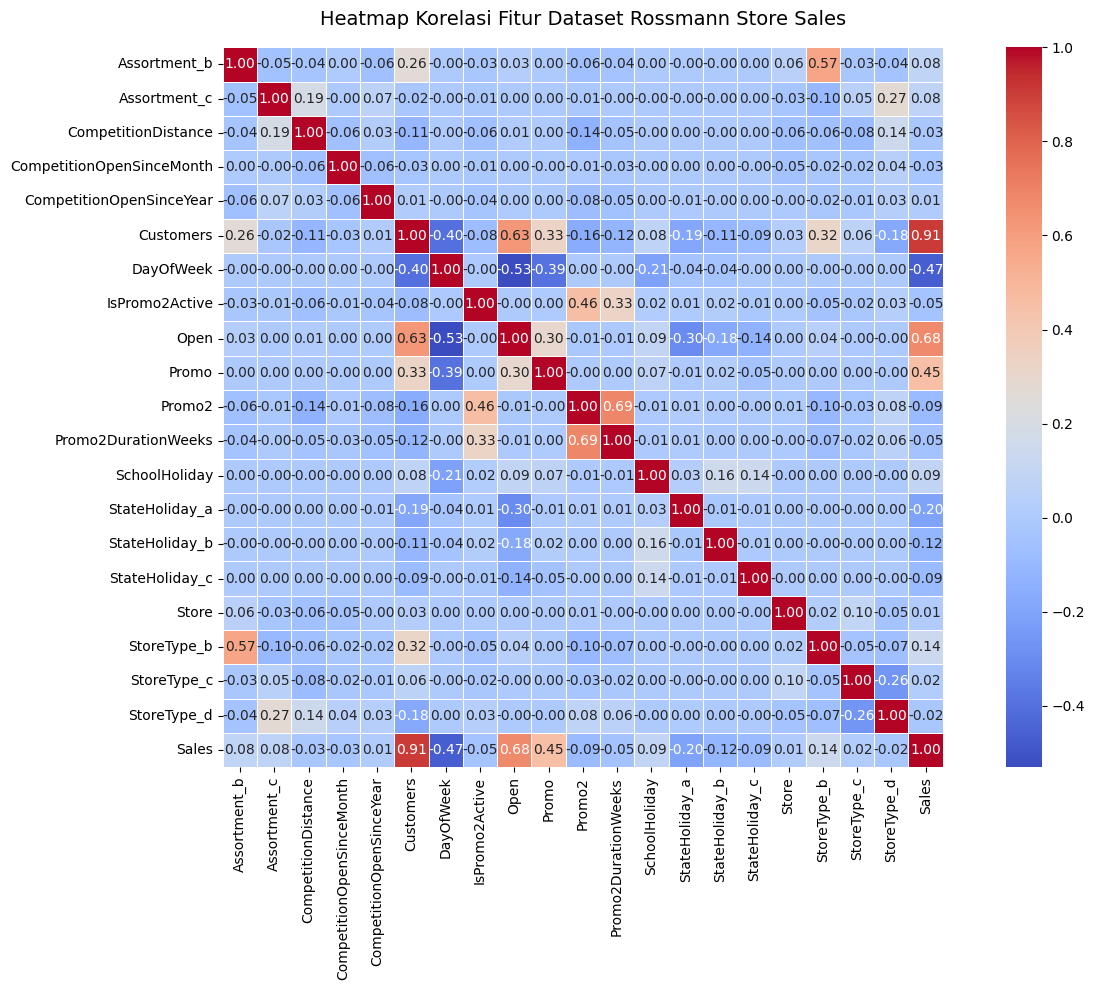

In [19]:
corr_matrix = series.corr(numeric_only=True)

# Extract only the correlation with the 'Sales' column
corr_sales = corr_matrix['Sales']

# Filter negative values only
corr_negative = corr_sales[corr_sales < 0].sort_values()

display(corr_negative)

plt.figure(figsize=(14, 10))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    cbar=True,
    square=True,
    linewidths=0.5
)
plt.title("Heatmap Korelasi Fitur Dataset Rossmann Store Sales", fontsize=14, pad=16)
plt.tight_layout()
plt.show()

##### 1.4 Store Count

Evaluate unique identifier cardinality.


In [10]:
print(f"Count stores: {series['Store'].nunique()}")

Count stores: 1115


### Feature Engineering and Data Cleaning

Generate synthetic features, apply transformations, and prune uninformative dimensions.


#### Feature Engineering

Implement derived attributes (e.g., active promotion durations).


##### Create the IsPromo2Active Column

Generate a binary indicator for active Promo2 months.


In [5]:
series['MonthStr'] = series['Date'].dt.strftime('%b')  # Contoh: 'Jan', 'Feb', ...

def is_promo2_active(row):
    if row['Promo2'] == 1 and isinstance(row['PromoInterval'], str):
        return 1 if row['MonthStr'] in row['PromoInterval'].split(',') else 0
    else:
        return 0

series['IsPromo2Active'] = series.apply(is_promo2_active, axis=1)

##### Create the Promo2DurationWeeks Feature

Calculate continuous active promotion duration based on start week/year.


In [6]:
series['Promo2DurationWeeks'] = np.where(
    series['Promo2'] == 1,
    (series['Date'].dt.year - series['Promo2SinceYear']) * 52 +
    (series['Date'].dt.isocalendar().week - series['Promo2SinceWeek']),
    0
)
series['Promo2DurationWeeks'] = series['Promo2DurationWeeks'].clip(lower=0).fillna(0)

##### One-hot encoding

Vectorize categorical features for gradient boosting compatibility.


In [7]:
cat_cols = [
    'StoreType', 
    'Assortment', 
    'StateHoliday',
]
series = pd.get_dummies(series, columns=cat_cols, drop_first=True)
boolean_cols = series.select_dtypes(include='bool').columns
series[boolean_cols] = series[boolean_cols].astype(int)
series.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,SchoolHoliday,CompetitionDistance,CompetitionOpenSinceMonth,...,IsPromo2Active,Promo2DurationWeeks,StoreType_b,StoreType_c,StoreType_d,Assortment_b,Assortment_c,StateHoliday_a,StateHoliday_b,StateHoliday_c
1017208,1115,2,2013-01-01,0,0,0,0,1,5350.0,NaN,...,0,31.0,0,0,1,0,1,1,0,0
1016473,379,2,2013-01-01,0,0,0,0,1,6630.0,NaN,...,0,0.0,0,0,1,0,0,1,0,0
1016472,378,2,2013-01-01,0,0,0,0,1,2140.0,8.0,...,0,0.0,0,0,0,0,1,1,0,0
1016471,377,2,2013-01-01,0,0,0,0,1,100.0,6.0,...,0,139.0,0,0,0,0,1,1,0,0
1016470,376,2,2013-01-01,0,0,0,0,1,160.0,8.0,...,0,0.0,0,0,0,0,0,1,0,0


##### Sort Columns

Standardize column ordering to ensure persistence compatibility across serialized Scaler artifacts.


In [37]:
# Ensure the 'Sales' target column is the rightmost column
target_col = 'Sales'
cols = sorted([c for c in series.columns if c != target_col]) + [target_col]
series = series[cols]
series.columns

Index(['Assortment_b', 'Assortment_c', 'CompetitionDistance',
       'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Customers',
       'Date', 'DayOfWeek', 'IsPromo2Active', 'MonthStr', 'Open', 'Promo',
       'Promo2', 'Promo2DurationWeeks', 'Promo2SinceWeek', 'Promo2SinceYear',
       'PromoInterval', 'SchoolHoliday', 'StateHoliday_a', 'StateHoliday_b',
       'StateHoliday_c', 'Store', 'StoreType_b', 'StoreType_c', 'StoreType_d',
       'Sales'],
      dtype='object')

#### Drop Null and Unnecessary Columns

1. The `Date` column is pruned (retained solely in visualization dataframes).
2. Spatial and temporal competitor metrics exhibiting excessive sparsity and negative target correlations are dropped.
3. Raw Promo2 tracking columns are dropped in favor of `IsPromo2Active`.


In [38]:
print("Sebelum di-drop:", series.shape)

series.drop(columns=[
    # 'CompetitionDistance', 
    # 'CompetitionOpenSinceMonth', 
    'CompetitionOpenSinceYear', 
    
    'Promo2SinceWeek', 
    'Promo2SinceYear', 
    'PromoInterval',
    'MonthStr',
    # 'Date',
    ], inplace=True, errors='ignore')
series.dropna(inplace=True)
print("Sesudah di-drop:", series.shape)

Sebelum di-drop: (1017209, 26)
Sesudah di-drop: (693861, 21)


## Modeling

Three forecasting pipelines are evaluated: standalone XGBoost, XGBoost with log-transformed targets, and the Linear Regression + XGBoost hybrid.


### XGBoost

Standalone XGBoost baseline utilizing GridSearchCV hyperparameter tuning on a chronological train/test split.


#### Training

Execute grid search optimization over the training subset.


In [10]:
# ==========================
# 4. Train-test data split
# ==========================
total_data = len(series)
train_size = int(total_data * 0.8)
test_size = total_data - train_size

train = series[:train_size]
test  = series[train_size:]

X_train = train.drop(columns=['Sales'])
y_train = train['Sales']
X_test  = test.drop(columns=['Sales'])
y_test  = test['Sales']

# ==========================
# 5. Scaling
# ==========================
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# ==========================
# 6. Grid Search XGBoost
# ==========================
# param_grid = {
#     'n_estimators': [50, 100, 200, 300, 400, 500],
#     'learning_rate': [0.01, 0.05, 0.1],
#     'max_depth': [3, 5, 7],
#     'subsample': [0.6, 0.8, 1.0],
#     'colsample_bytree': [0.6, 0.8, 1.0]
# }

param_grid = {
    'n_estimators': [900, 1100],
    'learning_rate': [0.2, 0.4],
    'max_depth': [9, 12],
    'subsample': [0.8, 2.0],
    'colsample_bytree': [0.8, 2.0]
}

tscv = TimeSeriesSplit(n_splits=3)

xgb = XGBRegressor(random_state=42)

grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring='neg_root_mean_squared_error',
    cv=tscv,
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)
best_params = grid_search.best_params_
 
print("Best RMSE:", -grid_search.best_score_)
print("Best Params:", grid_search.best_params_)

Fitting 3 folds for each of 32 candidates, totalling 96 fits
Best RMSE: 561.1606750488281
Best Params: {'colsample_bytree': 0.8, 'learning_rate': 0.2, 'max_depth': 9, 'n_estimators': 900, 'subsample': 0.8}


#### Testing

Evaluate baseline XGBoost performance on the test split.


In [11]:
xgb_model = XGBRegressor(
    objective='reg:squarederror', 
    n_estimators=best_params['n_estimators'], 
    max_depth=best_params['max_depth'],
    learning_rate=best_params['learning_rate'],
    # subsample=best_params['subsample'],
    # colsample_bytree=best_params['colsample_bytree'],
)

xgb_model.fit(X_train, y_train)
xgb_predictions = xgb_model.predict(X_test_scaled)

# compute RMSE
mse = mean_squared_error(y_test, xgb_predictions)
rmse = np.sqrt(mse)

print("RMSE:", rmse)
print("MSE:", mse)

RMSE: 6172.534325542467
MSE: 38100180.0


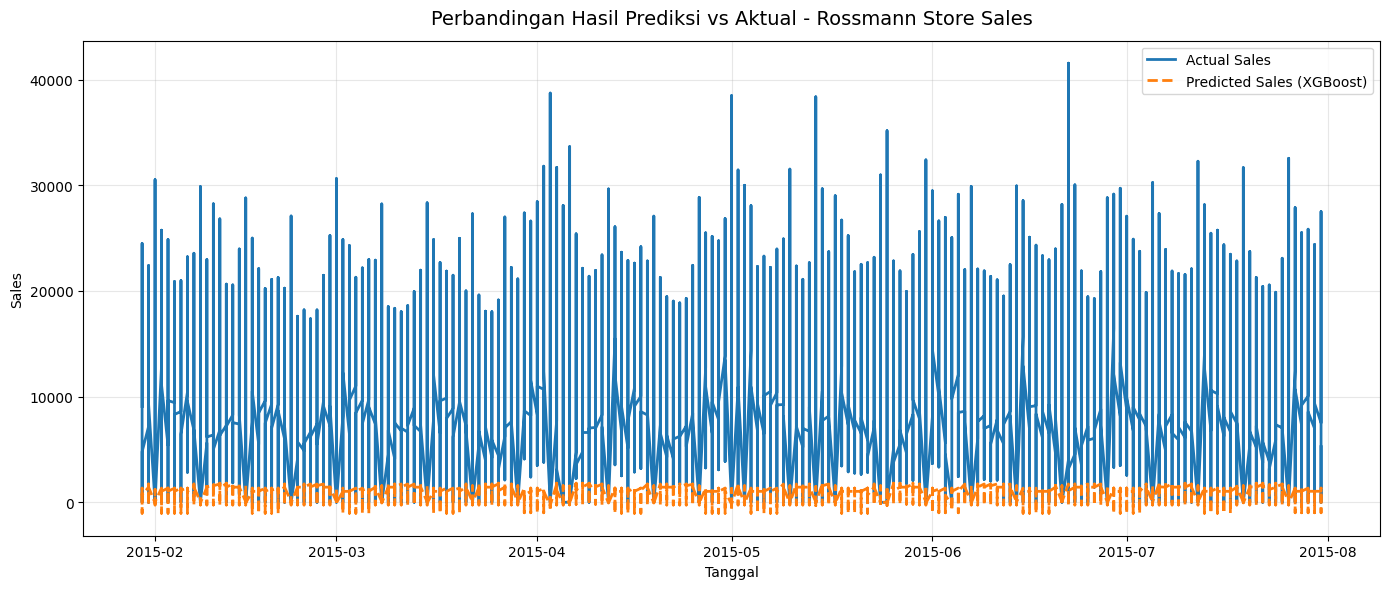

In [ ]:
dates = data.loc[test.index, 'Date']

results = pd.DataFrame({
    'Date': dates,
    'Actual_Sales': y_test.values,
    'Predicted_Sales': xgb_predictions
})

plt.figure(figsize=(14, 6))
plt.plot(results['Date'], results['Actual_Sales'], label='Actual Sales', linewidth=2)
plt.plot(results['Date'], results['Predicted_Sales'], label='Predicted Sales (XGBoost)', linestyle='--', linewidth=2)

plt.title('Perbandingan Hasil Prediksi vs Aktual - Rossmann Store Sales', fontsize=14, pad=12)
plt.xlabel('Tanggal')
plt.ylabel('Sales')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### XGBoost with Log Transformation

XGBoost trained with `log1p`-transformed sales targets to enhance robustness against severe distributional skew.


#### Training & Testing

Execute training and subsequent evaluation using logarithmic stabilization.


In [12]:
# ===============================================================
# 1. DEBUG INFORMATION
# ===============================================================
display("Using this data columns:")
display(series.columns.tolist())

# ===============================================================
# 1. FEATURE ENGINEERING: LOG TRANSFORMATION
# ===============================================================
data_to_transform = series.copy()

log_cols = ["Sales"]

for col in log_cols:
    data_to_transform[f"{col}_log"] = np.log1p(data_to_transform[col])

# Use the log version as features & target
data_to_train = data_to_transform.copy()
data_to_train.drop(columns=log_cols, inplace=True)

TARGET = "Sales_log"

# ===============================================================
# 2. TRAIN-TEST DATA SPLIT
# ===============================================================
total_data = len(data_to_train)
train_size = int(total_data * 0.8)

train = data_to_train[:train_size]
test = data_to_train[train_size:]

X_train = train.drop(columns=["Sales_log"])
y_train = train[TARGET]
X_test = test.drop(columns=["Sales_log"])
y_test = test[TARGET]

# ===============================================================
# 3. SCALING
# ===============================================================
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)


# ===============================================================
# 5. GRID SEARCH XGBOOST (TRAIN ON RESIDUALS)
# ===============================================================
# param_grid = {
#     'n_estimators': [500, 600, 700, 800],
#     'learning_rate': [0.05, 0.1, 0.2, 0.3],
#     'max_depth': [5, 7, 9, 11],
#     'subsample': [0.6, 0.8, 1.0],
#     'colsample_bytree': [0.6, 0.8, 1.0]
# }

param_grid = {
    'n_estimators': [900, 1100],
    'learning_rate': [0.2, 0.4],
    'max_depth': [9, 12],
    'subsample': [0.8, 2.0],
    'colsample_bytree': [0.8, 2.0]
}

# param_grid = {
#     'n_estimators': [500],
#     'learning_rate': [0.1],
#     'max_depth': [7],
#     'subsample': [0.6],
#     'colsample_bytree': [1.0]
# }

tscv = TimeSeriesSplit(n_splits=3)
xgb = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    tree_method="hist"
)

grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring="neg_root_mean_squared_error",
    cv=tscv,
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)
best_params = grid_search.best_params_
print("Best Params (XGB):", best_params)

xgb_best = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    tree_method="hist",
    **best_params,
)

xgb_best.fit(X_train_scaled, y_train)

# ===============================================================
# 6. XGBOOST PREDICTION
# ===============================================================
xgb_pred_log = xgb_best.predict(X_test_scaled)
# ===============================================================
# 7A. EVALUATION IN LOG SCALE (WITHOUT INVERSE)
# ===============================================================

# LR & Hybrid predictions in LOG scale
mse_hybrid_log = mean_squared_error(y_test, xgb_pred_log)
rmse_hybrid_log = np.sqrt(mse_hybrid_log)

print("=== LOG SCALE (Belum di-Inverse) ===")
print(f"MSE Hybrid (log) : {mse_hybrid_log:.5f}")
print(f"RMSE Hybrid (log): {rmse_hybrid_log:.5f}")
print()


# ===============================================================
# 7B. EVALUATION IN ORIGINAL SCALE (AFTER INVERSE)
# ===============================================================

# Convert back to original scale
y_test_real = np.expm1(y_test)
hybrid_pred_real = np.expm1(xgb_pred_log)

mse_hybrid_real = mean_squared_error(y_test_real, hybrid_pred_real)
rmse_hybrid_real = np.sqrt(mse_hybrid_real)

print("=== ORIGINAL SCALE (Setelah Inverse) ===")
print(f"MSE Hybrid (real) : {mse_hybrid_real:.3f}")
print(f"RMSE Hybrid (real): {rmse_hybrid_real:.3f}")
print()

'Using this data columns:'

['Assortment_b',
 'Assortment_c',
 'CompetitionDistance',
 'CompetitionOpenSinceMonth',
 'CompetitionOpenSinceYear',
 'Customers',
 'DayOfWeek',
 'IsPromo2Active',
 'Open',
 'Promo',
 'Promo2',
 'Promo2DurationWeeks',
 'SchoolHoliday',
 'StateHoliday_a',
 'StateHoliday_b',
 'StateHoliday_c',
 'Store',
 'StoreType_b',
 'StoreType_c',
 'StoreType_d',
 'Sales']

Fitting 3 folds for each of 32 candidates, totalling 96 fits
Best Params (XGB): {'colsample_bytree': 0.8, 'learning_rate': 0.2, 'max_depth': 9, 'n_estimators': 900, 'subsample': 0.8}
=== LOG SCALE (Belum di-Inverse) ===
MSE Hybrid (log) : 0.00537
RMSE Hybrid (log): 0.07328

=== ORIGINAL SCALE (Setelah Inverse) ===
MSE Hybrid (real) : 244572.061
RMSE Hybrid (real): 494.542



### Linear Regression + XGBoost

Hybrid architecture utilizing Linear Regression for global linear approximation, followed by XGBoost specifically targeted on minimizing the resulting predictive residuals.


#### Training

Execute grid search optimization over the training subset.


##### With Log Transform

Evaluate the hybrid architecture using varying transformations (Logarithmic and Box-Cox).


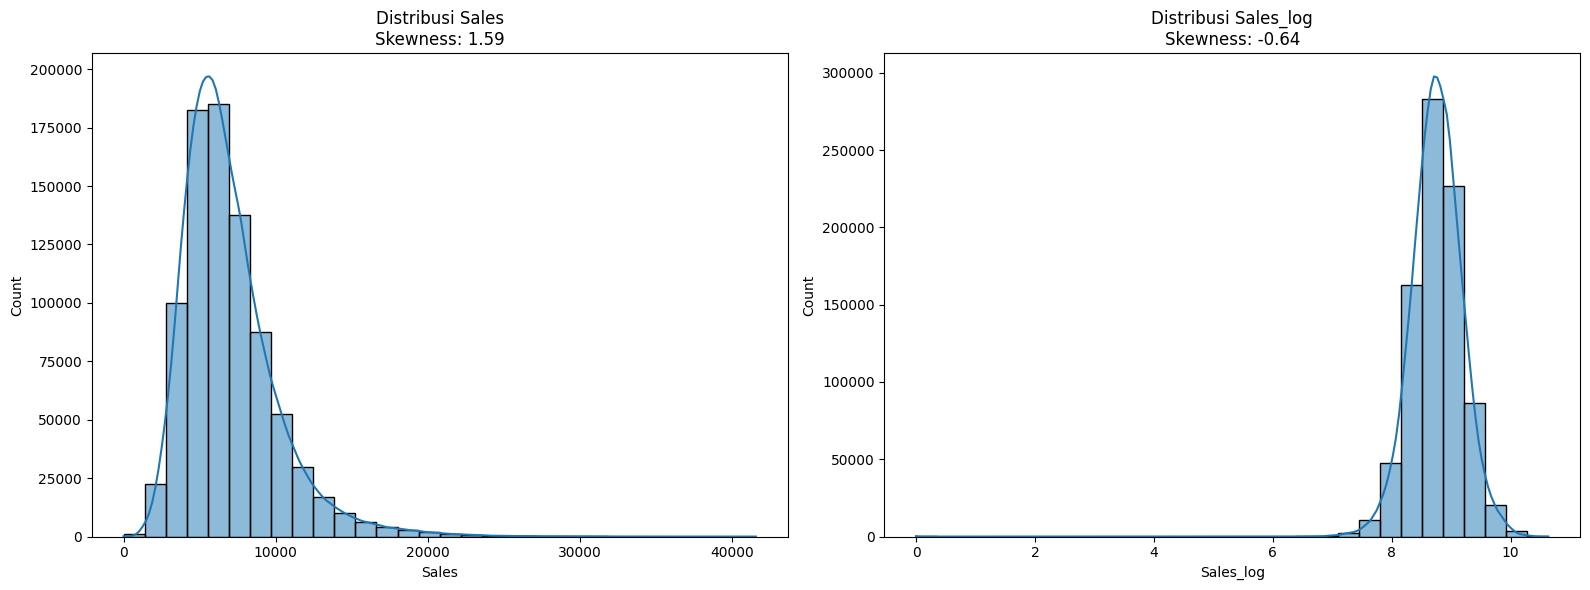

In [30]:
data_to_transform = series[series["Open"] == 1].copy()
log_cols = ["Sales"]

for col in log_cols:
    data_to_transform[f"{col}_log"] = np.log1p(data_to_transform[col])

cols_to_plot = ["Sales", "Sales_log"]

plt.figure(figsize=(16, 6))

for i, col in enumerate(cols_to_plot, 1):
    skewness = data_to_transform[col].skew()
    
    plt.subplot(1, 2, i)
    sns.histplot(data_to_transform[col].dropna(), kde=True, bins=30)
    plt.title(f"Distribusi {col}\nSkewness: {skewness:.2f}")
    plt.xlabel(col)
    plt.ylabel("Count")

plt.tight_layout()
plt.show()

###### Using Logarithmic (RMSE, MSE, R2, MAE)

Evaluate log-transformed hybrid performance using standard regression loss metrics.


In [43]:
# ===============================================================
# 1. DEBUG INFORMATION
# ===============================================================
display("Using this data columns:")
display(series.columns.tolist())

# ===============================================================
# 1. FEATURE ENGINEERING: LOG TRANSFORMATION
# ===============================================================
data_to_transform = series.copy()

log_cols = ["Sales"]

for col in log_cols:
    data_to_transform[f"{col}_log"] = np.log1p(data_to_transform[col])

# Use the log version as features & target
data_to_train = data_to_transform.copy()
data_to_train.drop(columns=log_cols, inplace=True)

TARGET = "Sales_log"

# ===============================================================
# 2. TRAIN-TEST DATA SPLIT
# ===============================================================
total_data = len(data_to_train)
train_size = int(total_data * 0.8)

train = data_to_train[:train_size]
test = data_to_train[train_size:]

X_train = train.drop(columns=["Sales_log", "Date"])
y_train = train.drop(columns="Date")[TARGET]
X_test = test.drop(columns=["Sales_log", "Date"])
y_test = test.drop(columns="Date")[TARGET]

# ===============================================================
# 4. TRAIN LINEAR REGRESSION (HYBRID PART)
# ===============================================================
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

lr_pred_train = lr_model.predict(X_train)
lr_pred_test = lr_model.predict(X_test)

residual_train = y_train - lr_pred_train

# ===============================================================
# 5. GRID SEARCH XGBOOST (TRAIN ON RESIDUALS)
# ===============================================================
param_grid = {
    'n_estimators': [100, 900],
    'learning_rate': [0.2, 0.3, 0.4],
    'max_depth': [6, 9, 12],
    'subsample': [0.8, 2.0],
    'colsample_bytree': [0.8, 2.0],
    'booster': ['gbtree'],
    'max_bin': [256]
}

tscv = TimeSeriesSplit(n_splits=3)
xgb = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    tree_method="hist"
)

grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring="neg_root_mean_squared_error",
    cv=tscv,
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train, residual_train)
best_params = grid_search.best_params_
print("Best Params (XGB):", best_params)

xgb_best = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    tree_method="hist",
    **best_params,
)

xgb_best.fit(X_train, residual_train)

# ===============================================================
# 6. HYBRID PREDICTION
# ===============================================================
residual_pred_test = xgb_best.predict(X_test)
hybrid_pred_log = lr_pred_test + residual_pred_test

# Convert back to original scale
hybrid_pred = np.expm1(hybrid_pred_log)
sales_actual = np.expm1(y_test)

# ===============================================================
# 7A. EVALUATION IN LOG SCALE (WITHOUT INVERSE)
# ===============================================================

# LR & Hybrid predictions in LOG scale
y_test_log = y_test
lr_pred_test_log = lr_pred_test
hybrid_pred_log = lr_pred_test + residual_pred_test

mse_hybrid_log = mean_squared_error(y_test_log, hybrid_pred_log)
rmse_hybrid_log = np.sqrt(mse_hybrid_log)
r2_hybrid_log = r2_score(y_test_log, hybrid_pred_log)
mae_hybrid_log = mean_absolute_error(y_test_log, hybrid_pred_log)


print("=== LOG SCALE (Belum di-Inverse) ===")
print(f"MSE Hybrid (log) : {mse_hybrid_log:.5f}")
print(f"RMSE Hybrid (log): {rmse_hybrid_log:.5f}")
print(f"R2 Hybrid (log): {r2_hybrid_log:.5f}")
print(f"MAE Hybrid (log): {mae_hybrid_log:.5f}")
print()


# ===============================================================
# 7B. EVALUATION IN ORIGINAL SCALE (AFTER INVERSE)
# ===============================================================

# Convert back to original scale
y_test_real = np.expm1(y_test_log)
lr_pred_real = np.expm1(lr_pred_test_log)
hybrid_pred_real = np.expm1(hybrid_pred_log)

mse_hybrid_real = mean_squared_error(y_test_real, hybrid_pred_real)
rmse_hybrid_real = np.sqrt(mse_hybrid_real)
r2_hybrid_real = r2_score(y_test_real, hybrid_pred_real)
mae_hybrid_real = mean_absolute_error(y_test_real, hybrid_pred_real)

print("=== ORIGINAL SCALE (Setelah Inverse) ===")
print(f"MSE Hybrid (real) : {mse_hybrid_real:.3f}")
print(f"RMSE Hybrid (real): {rmse_hybrid_real:.3f}")
print(f"R2 Hybrid (real): {r2_hybrid_real:.5f}")
print(f"MAE Hybrid (real): {mae_hybrid_real:.5f}")
print()

'Using this data columns:'

['Assortment_b',
 'Assortment_c',
 'CompetitionDistance',
 'CompetitionOpenSinceMonth',
 'Customers',
 'Date',
 'DayOfWeek',
 'IsPromo2Active',
 'Open',
 'Promo',
 'Promo2',
 'Promo2DurationWeeks',
 'SchoolHoliday',
 'StateHoliday_a',
 'StateHoliday_b',
 'StateHoliday_c',
 'Store',
 'StoreType_b',
 'StoreType_c',
 'StoreType_d',
 'Sales']

Fitting 3 folds for each of 72 candidates, totalling 216 fits
Best Params (XGB): {'booster': 'gbtree', 'colsample_bytree': 0.8, 'learning_rate': 0.2, 'max_bin': 256, 'max_depth': 6, 'n_estimators': 900, 'subsample': 0.8}
=== LOG SCALE (Belum di-Inverse) ===
MSE Hybrid (log) : 0.00502
RMSE Hybrid (log): 0.07088
R2 Hybrid (log): 0.99954
MAE Hybrid (log): 0.04666

=== ORIGINAL SCALE (Setelah Inverse) ===
MSE Hybrid (real) : 275930.272
RMSE Hybrid (real): 525.291
R2 Hybrid (real): 0.98164
MAE Hybrid (real): 312.08771



###### Using Logarithmic (RMSPE)

Evaluate log-transformed hybrid performance focusing on relative percentage error.


In [44]:
# ===============================================================
# 1. DEBUG INFORMATION
# ===============================================================
display("Using this data columns:")
display(series.columns.tolist())

# ===============================================================
# 1. FEATURE ENGINEERING: LOG TRANSFORMATION
# ===============================================================
data_to_transform = series[(series["Sales"] > 0)].copy()

log_cols = ["Sales"]

for col in log_cols:
    data_to_transform[f"{col}_log"] = np.log1p(data_to_transform[col])

# Use the log version as features & target
data_to_train = data_to_transform.copy()
data_to_train.drop(columns=log_cols, inplace=True)

TARGET = "Sales_log"

# ===============================================================
# 2. TRAIN-TEST DATA SPLIT
# ===============================================================
total_data = len(data_to_train)
train_size = int(total_data * 0.8)

train = data_to_train[:train_size]
test = data_to_train[train_size:]

X_train = train.drop(columns=["Sales_log", "Date"])
y_train = train.drop(columns="Date")[TARGET]
X_test = test.drop(columns=["Sales_log", "Date"])
y_test = test.drop(columns="Date")[TARGET]

# ===============================================================
# 4. TRAIN LINEAR REGRESSION (HYBRID PART)
# ===============================================================
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

lr_pred_train = lr_model.predict(X_train)
lr_pred_test = lr_model.predict(X_test)

residual_train = y_train - lr_pred_train

# ===============================================================
# 5. GRID SEARCH XGBOOST (TRAIN ON RESIDUALS)
# ===============================================================
param_grid = {
    'n_estimators': [100, 900],
    'learning_rate': [0.2, 0.3, 0.4],
    'max_depth': [6, 9, 12],
    'subsample': [0.8, 2.0],
    'colsample_bytree': [0.8, 2.0],
    'booster': ['gbtree'],
    'max_bin': [256]
}

tscv = TimeSeriesSplit(n_splits=3)
xgb = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    tree_method="hist"
)

grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring="neg_root_mean_squared_error",
    cv=tscv,
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train, residual_train)
best_params = grid_search.best_params_
print("Best Params (XGB):", best_params)

xgb_best = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    tree_method="hist",
    **best_params,
)

xgb_best.fit(X_train, residual_train)

# ===============================================================
# 6. HYBRID PREDICTION
# ===============================================================
residual_pred_test = xgb_best.predict(X_test)
hybrid_pred_log = lr_pred_test + residual_pred_test

# Convert back to original scale
hybrid_pred = np.expm1(hybrid_pred_log)
sales_actual = np.expm1(y_test)

# ===============================================================
# 7A. EVALUATION IN LOG SCALE (WITHOUT INVERSE)
# ===============================================================

# LR & Hybrid predictions in LOG scale
y_test_log = y_test
lr_pred_test_log = lr_pred_test
hybrid_pred_log = lr_pred_test + residual_pred_test

rmspe_hybrid_log = rmspe(y_test_log, hybrid_pred_log)


print("=== LOG SCALE (Belum di-Inverse) ===")
print(f"RMSPE Hybrid (log): {rmspe_hybrid_log:.5f}")
print()


# ===============================================================
# 7B. EVALUATION IN ORIGINAL SCALE (AFTER INVERSE)
# ===============================================================

# Convert back to original scale
y_test_real = np.expm1(y_test_log)
lr_pred_real = np.expm1(lr_pred_test_log)
hybrid_pred_real = np.expm1(hybrid_pred_log)

mse_hybrid_real = mean_squared_error(y_test_real, hybrid_pred_real)
rmse_hybrid_real = np.sqrt(mse_hybrid_real)
rmspe_hybrid_real = rmspe(y_test_real, hybrid_pred_real)
r2_hybrid_real = r2_score(y_test_real, hybrid_pred_real)
mae_hybrid_real = mean_absolute_error(y_test_real, hybrid_pred_real)

print("=== ORIGINAL SCALE (Setelah Inverse) ===")
print(f"RMSPE Hybrid (real): {rmspe_hybrid_real:.5f}")
print()

'Using this data columns:'

['Assortment_b',
 'Assortment_c',
 'CompetitionDistance',
 'CompetitionOpenSinceMonth',
 'Customers',
 'Date',
 'DayOfWeek',
 'IsPromo2Active',
 'Open',
 'Promo',
 'Promo2',
 'Promo2DurationWeeks',
 'SchoolHoliday',
 'StateHoliday_a',
 'StateHoliday_b',
 'StateHoliday_c',
 'Store',
 'StoreType_b',
 'StoreType_c',
 'StoreType_d',
 'Sales']

Fitting 3 folds for each of 72 candidates, totalling 216 fits
Best Params (XGB): {'booster': 'gbtree', 'colsample_bytree': 0.8, 'learning_rate': 0.2, 'max_bin': 256, 'max_depth': 6, 'n_estimators': 900, 'subsample': 0.8}
=== LOG SCALE (Belum di-Inverse) ===
RMSPE Hybrid (log): 0.00799

=== ORIGINAL SCALE (Setelah Inverse) ===
RMSPE Hybrid (real): 0.06775



In [25]:
# # uncomment if needed
# version_tag = "1.4"
# features_used = list(X_train.columns)

# save_model(scaler, "scaler", version_tag)
# save_model(lr_model, "lr_model", version_tag)
# save_model(xgb_best, "xgb_model", version_tag)
# save_features(features_used, version_tag)

✅ Saved: d:\Work-Env\ITEC\forecasting-medicine-disertasi\LRXGBoost\models\v1.4\scaler.pkl
✅ Saved: d:\Work-Env\ITEC\forecasting-medicine-disertasi\LRXGBoost\models\v1.4\lr_model.pkl
✅ Saved: d:\Work-Env\ITEC\forecasting-medicine-disertasi\LRXGBoost\models\v1.4\xgb_model.pkl
📄 Features saved: d:\Work-Env\ITEC\forecasting-medicine-disertasi\LRXGBoost\models\v1.4\features.pkl


'd:\\Work-Env\\ITEC\\forecasting-medicine-disertasi\\LRXGBoost\\models\\v1.4\\features.pkl'

###### With Logarithmic and RMSPE Custom Loss Function

Train using a mathematically customized loss function explicitly minimizing RMSPE during gradient descent.


In [19]:
# ===============================================================
# IMPORTS
# ===============================================================
import numpy as np
import pandas as pd

from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.metrics import make_scorer

from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from xgboost import XGBRegressor

# Custom RMSPE scorer
def rmspe(y_true, y_pred):
    y_true = np.where(y_true == 0, 1e-6, y_true)
    return np.sqrt(np.mean(((y_true - y_pred) / y_true) ** 2))

def rmspe_sklearn(y_true, y_pred):
    return rmspe(y_true, y_pred)

rmspe_scorer = make_scorer(rmspe_sklearn, greater_is_better=False)

# ===============================================================
# 1. DEBUG INFORMATION
# ===============================================================
display("Using these data columns:")
display(series.columns.tolist())

# ===============================================================
# 1. FEATURE ENGINEERING: LOG TRANSFORMATION
# ===============================================================
data_to_transform = series[series["Open"] == 1].copy()

log_cols = ["Sales"]

for col in log_cols:
    data_to_transform[f"{col}_log"] = np.log1p(data_to_transform[col])

# Use the log version as features & target
data_to_train = data_to_transform.copy()
data_to_train.drop(columns=log_cols, inplace=True)

TARGET = "Sales_log"

# ===============================================================
# 2. TRAIN-TEST SPLIT (TIME-ORDERED)
# ===============================================================
total_data = len(data_to_train)
train_size = int(total_data * 0.8)

train = data_to_train[:train_size]
test = data_to_train[train_size:]

X_train = train.drop(columns=[TARGET])
y_train = train[TARGET]

X_test = test.drop(columns=[TARGET])
y_test = test[TARGET]

# ===============================================================
# 3. SCALING
# ===============================================================
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# ===============================================================
# 4. TRAIN LINEAR REGRESSION (HYBRID PART 1)
# ===============================================================
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

lr_pred_train = lr_model.predict(X_train_scaled)
lr_pred_test  = lr_model.predict(X_test_scaled)

# Residual training target
residual_train = y_train - lr_pred_train

# ===============================================================
# 5. GRID SEARCH XGBOOST (TRAIN RESIDUAL)
# ===============================================================
# param_grid = {
#     'n_estimators': [300, 500],
#     'learning_rate': [0.05, 0.1],
#     'max_depth': [5, 7],
#     'subsample': [0.6, 0.8],
#     'colsample_bytree': [0.6, 0.8]
# }

param_grid = {
    'n_estimators': [700, 900],
    'learning_rate': [0.2, 0.4],
    'max_depth': [9, 12],
    'subsample': [0.8, 2.0],
    'colsample_bytree': [0.8, 2.0]
}

tscv = TimeSeriesSplit(n_splits=3)

xgb = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    tree_method="hist"
)

grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring=rmspe_scorer,   # <===== PENTING
    cv=tscv,
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train_scaled, residual_train)
best_params = grid_search.best_params_

print("Best Params (XGB):", best_params)

# ===============================================================
# TRAIN FINAL XGB (HYBRID PART 2)
# ===============================================================
xgb_best = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    tree_method="hist",
    **best_params,
)

xgb_best.fit(X_train_scaled, residual_train)

# ===============================================================
# 6. HYBRID PREDICTION
# ===============================================================
residual_pred_test = xgb_best.predict(X_test_scaled)
hybrid_pred_log = lr_pred_test + residual_pred_test

# Reverse log transform
hybrid_pred_real = np.expm1(hybrid_pred_log)
lr_pred_real = np.expm1(lr_pred_test)
y_test_real = np.expm1(y_test)

# ===============================================================
# 7A. EVALUATION – LOG SCALE
# ===============================================================
y_test_log = y_test
lr_pred_test_log = lr_pred_test

mse_lr_log = mean_squared_error(y_test_log, lr_pred_test_log)
mse_hybrid_log = mean_squared_error(y_test_log, hybrid_pred_log)

rmse_lr_log = np.sqrt(mse_lr_log)
rmse_hybrid_log = np.sqrt(mse_hybrid_log)

print("=== LOG SCALE ===")
print(f"MSE LR (log)     : {mse_lr_log:.5f}")
print(f"MSE Hybrid (log) : {mse_hybrid_log:.5f}")
print(f"RMSE LR (log)    : {rmse_lr_log:.5f}")
print(f"RMSE Hybrid (log): {rmse_hybrid_log:.5f}")
print()

# ===============================================================
# 7B. EVALUATION – ORIGINAL SCALE
# ===============================================================
mse_lr_real = mean_squared_error(y_test_real, lr_pred_real)
mse_hybrid_real = mean_squared_error(y_test_real, hybrid_pred_real)

rmse_lr_real = np.sqrt(mse_lr_real)
rmse_hybrid_real = np.sqrt(mse_hybrid_real)

rmspe_lr_real = rmspe(y_test_real, lr_pred_real)
rmspe_hybrid_real = rmspe(y_test_real, hybrid_pred_real)

print("=== ORIGINAL SCALE ===")
print(f"MSE LR (real)     : {mse_lr_real:.3f}")
print(f"MSE Hybrid (real) : {mse_hybrid_real:.3f}")
print(f"RMSE LR (real)    : {rmse_lr_real:.3f}")
print(f"RMSE Hybrid (real): {rmse_hybrid_real:.3f}")
print(f"RMSPE LR (real)   : {rmspe_lr_real:.5f}")
print(f"RMSPE Hybrid(real): {rmspe_hybrid_real:.5f}")


'Using these data columns:'

['Assortment_b',
 'Assortment_c',
 'CompetitionDistance',
 'CompetitionOpenSinceMonth',
 'CompetitionOpenSinceYear',
 'Customers',
 'DayOfWeek',
 'IsPromo2Active',
 'Open',
 'Promo',
 'Promo2',
 'Promo2DurationWeeks',
 'SchoolHoliday',
 'StateHoliday_a',
 'StateHoliday_b',
 'StateHoliday_c',
 'Store',
 'StoreType_b',
 'StoreType_c',
 'StoreType_d',
 'Sales']

Fitting 3 folds for each of 32 candidates, totalling 96 fits
Best Params (XGB): {'colsample_bytree': 0.8, 'learning_rate': 0.2, 'max_depth': 9, 'n_estimators': 900, 'subsample': 0.8}
=== LOG SCALE ===
MSE LR (log)     : 0.04454
MSE Hybrid (log) : 0.00607
RMSE LR (log)    : 0.21104
RMSE Hybrid (log): 0.07789

=== ORIGINAL SCALE ===
MSE LR (real)     : 9812327.234
MSE Hybrid (real) : 334127.904
RMSE LR (real)    : 3132.463
RMSE Hybrid (real): 578.038
RMSPE LR (real)   : 10765385.96361
RMSPE Hybrid(real): 2851274.92311


In [20]:
# # uncomment if needed

# features_used = list(X_train.columns)

# save_model(scaler, "scaler", "1.2")
# save_model(lr_model, "lr_model", "1.2")
# save_model(xgb_best, "xgb_model", "1.2")
# save_features(features_used, "1.2")

✅ Saved: d:\Work-Env\ITEC\forecasting-medicine-disertasi\LRXGBoost\models\v1.2\scaler.pkl
✅ Saved: d:\Work-Env\ITEC\forecasting-medicine-disertasi\LRXGBoost\models\v1.2\lr_model.pkl
✅ Saved: d:\Work-Env\ITEC\forecasting-medicine-disertasi\LRXGBoost\models\v1.2\xgb_model.pkl
📄 Features saved: d:\Work-Env\ITEC\forecasting-medicine-disertasi\LRXGBoost\models\v1.2\features.pkl


'd:\\Work-Env\\ITEC\\forecasting-medicine-disertasi\\LRXGBoost\\models\\v1.2\\features.pkl'

###### Using Box-Cox

Evaluate alternative variance stabilization via Box-Cox transformations.


In [ ]:
# ===============================================================
# A. FEATURE ENGINEERING: BOX-COX TRANSFORMATION
# ===============================================================
from scipy.stats import boxcox

data_bc = series[(series["Open"] == 1) & (series["Sales"] > 0)].copy()

# Box-Cox transformation
sales_bc, lambda_bc = boxcox(data_bc["Sales"])

data_bc["Sales_boxcox"] = sales_bc

print("Lambda Box-Cox:", lambda_bc)

# Use Box-Cox as the target
data_to_train = data_bc.copy()
data_to_train.drop(columns=["Sales"], inplace=True)

TARGET = "Sales_boxcox"

# ===============================================================
# TRAIN-TEST DATA SPLIT
# ===============================================================
total_data = len(data_to_train)
train_size = int(total_data * 0.8)

train = data_to_train[:train_size]
test = data_to_train[train_size:]

X_train = train.drop(columns=[TARGET])
y_train = train[TARGET]
X_test = test.drop(columns=[TARGET])
y_test = test[TARGET]

# ===============================================================
# SCALING
# ===============================================================
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ===============================================================
# LINEAR REGRESSION (HYBRID STEP)
# ===============================================================
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

lr_pred_train = lr_model.predict(X_train_scaled)
lr_pred_test = lr_model.predict(X_test_scaled)

residual_train = y_train - lr_pred_train

# ===============================================================
# GRID SEARCH XGBOOST (RESIDUAL MODEL)
# ===============================================================
tscv = TimeSeriesSplit(n_splits=5)
xgb = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    tree_method="hist"
)

param_grid = {
    'n_estimators': [900, 1100],
    'learning_rate': [0.2, 0.4],
    'max_depth': [9, 12],
    'subsample': [0.8, 2.0],
    'colsample_bytree': [0.8, 2.0]
}

grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring="neg_root_mean_squared_error",
    cv=tscv,
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train_scaled, residual_train)
best_params = grid_search.best_params_
print("Best Params (XGB - BoxCox):", best_params)

xgb_bc = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    tree_method="hist",
    **best_params
)
xgb_bc.fit(X_train_scaled, residual_train)

# ===============================================================
# HYBRID PREDICTION (BOX-COX SCALE)
# ===============================================================
residual_pred_test = xgb_bc.predict(X_test_scaled)
hybrid_pred_bc = lr_pred_test + residual_pred_test

# ===============================================================
# 7A. EVALUATION IN BOX-COX SCALE (BEFORE INVERSE)
# ===============================================================

y_test_bc = y_test  # keep in Box-Cox scale
lr_pred_bc = lr_pred_test
hybrid_pred_bc_scale = hybrid_pred_bc  # hybrid in Box-Cox scale

mse_lr_bc = mean_squared_error(y_test_bc, lr_pred_bc)
mse_hybrid_bc = mean_squared_error(y_test_bc, hybrid_pred_bc_scale)

rmse_lr_bc = np.sqrt(mse_lr_bc)
rmse_hybrid_bc = np.sqrt(mse_hybrid_bc)

print("=== BOX-COX SCALE (Belum di-Inverse) ===")
print(f"MSE LR (BoxCox)     : {mse_lr_bc:.5f}")
print(f"MSE Hybrid (BoxCox) : {mse_hybrid_bc:.5f}")
print(f"RMSE LR (BoxCox)    : {rmse_lr_bc:.5f}")
print(f"RMSE Hybrid (BoxCox): {rmse_hybrid_bc:.5f}")
print()

# ===============================================================
# 7B. EVALUATION IN ORIGINAL SCALE (AFTER INVERSE)
# ===============================================================

def inv_boxcox(y, lam):
    if lam == 0:
        return np.exp(y)
    return np.exp(np.log(lam * y + 1) / lam)

y_test_real = inv_boxcox(y_test.values, lambda_bc)
lr_pred_real = inv_boxcox(lr_pred_test, lambda_bc)
hybrid_pred_real = inv_boxcox(hybrid_pred_bc, lambda_bc)

mse_lr_real = mean_squared_error(y_test_real, lr_pred_real)
mse_hybrid_real = mean_squared_error(y_test_real, hybrid_pred_real)

rmse_lr_real = np.sqrt(mse_lr_real)
rmse_hybrid_real = np.sqrt(mse_hybrid_real)

print("=== ORIGINAL SCALE (Setelah Inverse BoxCox) ===")
print(f"MSE LR (real)     : {mse_lr_real:.3f}")
print(f"MSE Hybrid (real) : {mse_hybrid_real:.3f}")
print(f"RMSE LR (real)    : {rmse_lr_real:.3f}")
print(f"RMSE Hybrid (real): {rmse_hybrid_real:.3f}")
print()


Lambda Box-Cox: 0.09997258365289693
Fitting 5 folds for each of 32 candidates, totalling 160 fits
Best Params (XGB - BoxCox): {'colsample_bytree': 0.8, 'learning_rate': 0.2, 'max_depth': 9, 'n_estimators': 900, 'subsample': 0.8}
=== BOX-COX SCALE (Belum di-Inverse) ===
MSE LR (BoxCox)     : 0.23668
MSE Hybrid (BoxCox) : 0.02853
RMSE LR (BoxCox)    : 0.48650
RMSE Hybrid (BoxCox): 0.16892

=== ORIGINAL SCALE (Setelah Inverse BoxCox) ===
MSE LR (real)     : 5232407.546
MSE Hybrid (real) : 319407.367
RMSE LR (real)    : 2287.446
RMSE Hybrid (real): 565.161



: 

##### Without Log Transform

Baseline hybrid evaluation lacking target transformations.


In [27]:
# data_to_train = series.copy()
data_to_train = series[(series["Sales"] > 0)].copy()

# ===============================================================
# 3. TRAIN-TEST DATA SPLIT
# ===============================================================
total_data = len(data_to_train)
train_size = int(total_data * 0.8)

train = data_to_train[:train_size]
test = data_to_train[train_size:]

X_train = train.drop(columns=['Sales', 'Date'])
y_train = train['Sales']
X_test  = test.drop(columns=['Sales', 'Date'])
y_test  = test['Sales']

# ===============================================================
# 4. SCALING
# ===============================================================
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# ===============================================================
# 5. TRAIN LINEAR REGRESSION
# ===============================================================
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

# Predictions and residuals
lr_pred_train = lr_model.predict(X_train_scaled)
lr_pred_test = lr_model.predict(X_test_scaled)
residual_train = y_train - lr_pred_train  # error on training data

# ===============================================================
# 6. GRID SEARCH FOR XGBOOST (TRAIN ON RESIDUALS)
# ===============================================================
# param_grid = {
#     'n_estimators': [900, 1500],
#     'learning_rate': [0.2, 0.4],
#     'max_depth': [9, 12],
#     'subsample': [0.8, 2.0],
#     'colsample_bytree': [0.8, 2.0]
# }
param_grid = {
    'n_estimators': [500, 600, 700, 900, 1100],
    'learning_rate': [0.05, 0.1, 0.2, 0.3, 0.4],
    'max_depth': [5, 7, 9, 11, 13],
    'subsample': [0.6, 0.8, 1.0, 2.0],
    'colsample_bytree': [0.6, 0.8, 1.0, 2.0]
}


tscv = TimeSeriesSplit(n_splits=3)
xgb = XGBRegressor(objective='reg:squarederror', random_state=42)

grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring='neg_root_mean_squared_error',
    cv=tscv,
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)
best_params = grid_search.best_params_
print("Best Params (XGB):", best_params)

# Re-train with the best parameters
xgb_best = XGBRegressor(objective='reg:squarederror', random_state=42, **best_params)
xgb_best.fit(X_train_scaled, residual_train)

# ===============================================================
# 7. HYBRID PREDICTION
# ===============================================================
residual_pred_test = xgb_best.predict(X_test_scaled)
hybrid_pred = lr_pred_test + residual_pred_test

# ===============================================================
# 8. EVALUATION
# ===============================================================
mse_xgb = mean_squared_error(y_test, hybrid_pred)
rmse_xgb = np.sqrt(mse_xgb)
rmspe_hybrid = rmspe(y_test, hybrid_pred)
r2_xgb = r2_score(y_test, hybrid_pred)
mae_xgb = mean_absolute_error(y_test, hybrid_pred)

print(f"MSE Hybrid : {mse_xgb:.3f}")
print(f"RMSE Hybrid : {rmse_xgb:.3f}")
print(f"RMSPE Hybrid : {rmspe_hybrid:.3f}")
print(f"R² Hybrid   : {r2_xgb:.3f}")
print(f"MAE Hybrid   : {mae_xgb:.3f}")

Fitting 3 folds for each of 2000 candidates, totalling 6000 fits


PicklingError: Could not pickle the task to send it to the workers.

#### Save Model

Serialize optimal models and scaler artifacts for deployment testing.


In [80]:
# joblib.dump(scaler, 'models/scaler.best.pkl')
# joblib.dump(lr_model, 'models/lr_model.best.pkl')
# joblib.dump(xgb_best, 'models/xgb_model.best.pkl')

# print("Model and scaler successfully saved to 'models/' folder")

✅ Model dan scaler berhasil disimpan di folder 'models/'


#### Testing & Visualization

Graphical analysis of prediction trajectories.


##### Testing with Transformed Sales (Logarithmic)

Evaluate predictions generated within the transformed coordinate space.


In [34]:
# ===============================================================
# LOAD MODEL
# ===============================================================
version = 'v1.3'
scaler = joblib.load(f"models/{version}/scaler.pkl")
lr_model = joblib.load(f"models/{version}/lr_model.pkl")
xgb_model = joblib.load(f"models/{version}/xgb_model.pkl")

# ===============================================================
# 1. FEATURE ENGINEERING: LOG TRANSFORMATION
# ===============================================================
data_to_transform = series[series["Sales"] > 0].copy()

log_cols = ["Sales"]
for col in log_cols:
    data_to_transform[f"{col}_log"] = np.log1p(data_to_transform[col])

# Use the log version as features & target
data_to_train = data_to_transform.copy()
data_to_train.drop(columns=log_cols, inplace=True)

TARGET = "Sales_log"

# ===============================================================
# 3. TRAIN-TEST DATA SPLIT
# ===============================================================
total_data = len(data_to_train)
train_size = int(total_data * 0.8)

train = data_to_train[:train_size]
test = data_to_train[train_size:]

X_train = train.drop(columns=[TARGET, "Date"])
y_train = train[TARGET]
X_test = test.drop(columns=[TARGET, "Date"])
y_test = test[TARGET]

# ===============================================================
# 4. SCALING
# ===============================================================
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ===============================================================
# 5. TESTING
# ===============================================================
lr_pred_log = lr_model.predict(X_test_scaled)
xgb_pred_log = xgb_model.predict(X_test_scaled)
display(xgb_model.get_params)
# Hybrid prediction in log-scale
hybrid_pred_log = lr_pred_log + xgb_pred_log

# ===============================================================
# 6. EVALUATION — LOG SCALE
# ===============================================================
mse_log = mean_squared_error(y_test, hybrid_pred_log)
rmse_log = np.sqrt(mse_log)
mae_log = mean_absolute_error(y_test, hybrid_pred_log)
r2_log = r2_score(y_test, hybrid_pred_log)

# RMSPE is not meaningful in log-scale — not computed
print("===== HYBRID MODEL METRIC (Log Scale) =====")
print(f"MSE (log)  : {mse_log:.6f}")
print(f"RMSE (log) : {rmse_log:.6f}")
print(f"MAE (log)  : {mae_log:.6f}")
print(f"R2 (log)   : {r2_log:.6f}")

# ===============================================================
# 7. CONVERT BACK TO ORIGINAL SCALE
# ===============================================================
y_test_real = np.expm1(y_test)
lr_pred_real = np.expm1(lr_pred_log)
xgb_pred_real = np.expm1(xgb_pred_log)
hybrid_pred_real = np.expm1(hybrid_pred_log)

# ===============================================================
# 8. EVALUATION — ORIGINAL SALES SCALE
# ===============================================================
mse_real = mean_squared_error(y_test_real, hybrid_pred_real)
rmse_real = np.sqrt(mse_real)
mae_real = mean_absolute_error(y_test_real, hybrid_pred_real)
r2_real = r2_score(y_test_real, hybrid_pred_real)

# RMSPE (Root Mean Squared Percentage Error)
eps = 1e-9
rmspe_real = rmspe(y_test_real, hybrid_pred_real)

print("\n===== HYBRID MODEL METRIC (Original Sales Scale) =====")
print(f"MSE        : {mse_real:.3f}")
print(f"RMSE       : {rmse_real:.3f}")
print(f"MAE        : {mae_real:.3f}")
print(f"R2         : {r2_real:.5f}")
print(f"RMSPE      : {rmspe_real:.5f}")

<bound method XGBModel.get_params of XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.2, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=9,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=900,
             n_jobs=None, num_parallel_tree=None, ...)>

===== HYBRID MODEL METRIC (Log Scale) =====
MSE (log)  : 62.753693
RMSE (log) : 7.921723
MAE (log)  : 7.920722
R2 (log)   : -350.540978

===== HYBRID MODEL METRIC (Original Sales Scale) =====
MSE        : 59752336.597
RMSE       : 7729.964
MAE        : 7084.712
R2         : -5.24665
RMSPE      : 0.99980


##### Visualization with Transformed Sales (Logarithmic)

Plot log-space predictions.


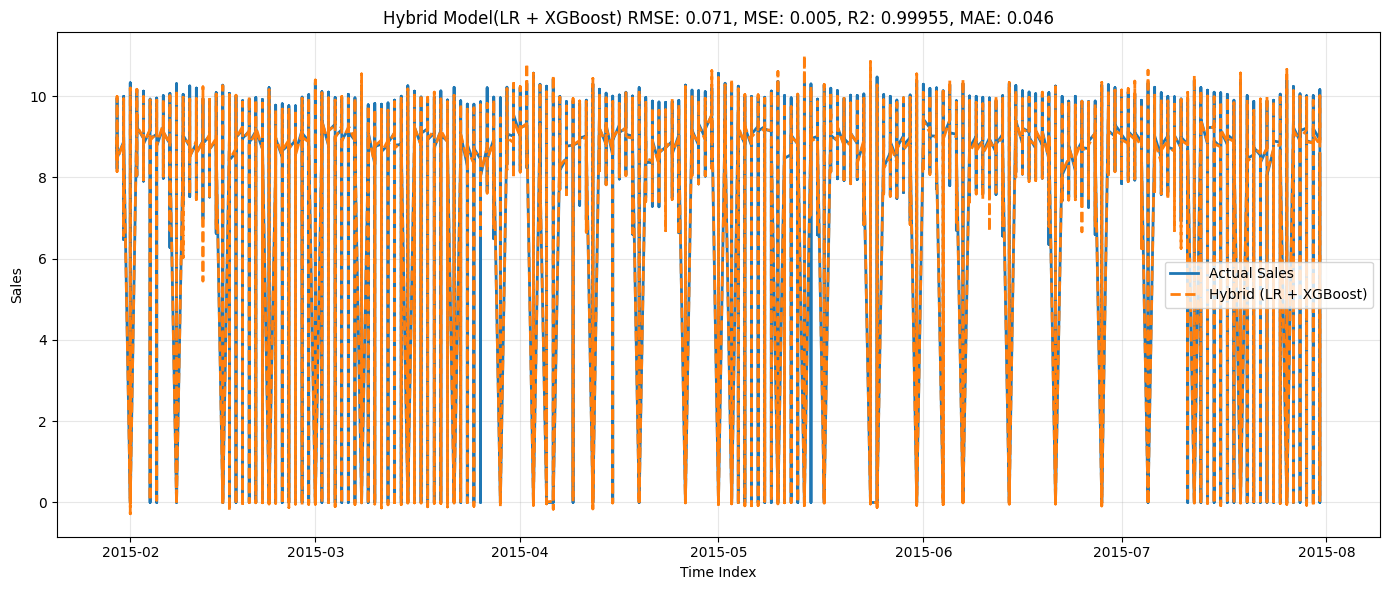

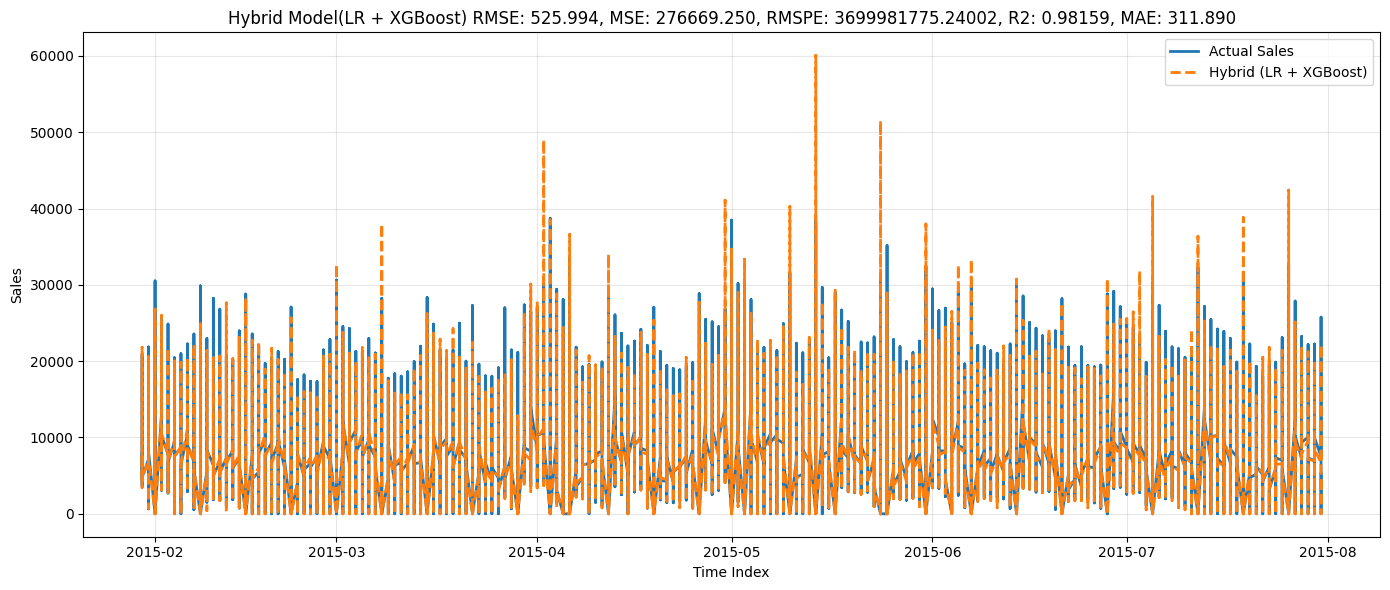

In [17]:
# ===============================================================
# 9. VISUALIZATION with Transformed Sales Data
# ===============================================================
visualization_data = pd.DataFrame({
    'date': test.Date,
    'actual_sales': y_test.values,
    'pred_hybrid': hybrid_pred_log,
})

plt.figure(figsize=(14,6))
plt.plot(visualization_data['date'], visualization_data['actual_sales'], label='Actual Sales', linewidth=2)
plt.plot(visualization_data['date'], visualization_data['pred_hybrid'], label='Hybrid (LR + XGBoost)', linestyle='--', linewidth=2)
plt.title(f"Hybrid Model(LR + XGBoost) RMSE: {rmse_log:.3f}, MSE: {mse_log:.3f}, R2: {r2_log:.5f}, MAE: {mae_log:.3f}")
plt.xlabel('Time Index')
plt.ylabel('Sales')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ===============================================================
# 9. VISUALIZATION with Original Sales
# ===============================================================
visualization_data = pd.DataFrame({
    'date': test.Date,
    'actual_sales': y_test_real.values,
    'pred_hybrid': hybrid_pred_real,
})

plt.figure(figsize=(14,6))
plt.plot(visualization_data['date'], visualization_data['actual_sales'], label='Actual Sales', linewidth=2)
plt.plot(visualization_data['date'], visualization_data['pred_hybrid'], label='Hybrid (LR + XGBoost)', linestyle='--', linewidth=2)
plt.title(f"Hybrid Model(LR + XGBoost) RMSE: {rmse_real:.3f}, MSE: {mse_real:.3f}, RMSPE: {rmspe_real:.5f}, R2: {r2_real:.5f}, MAE: {mae_real:.3f}")
plt.xlabel('Time Index')
plt.ylabel('Sales')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
scaler = joblib.load('models/scaler.best.pkl')
lr_model = joblib.load('models/lr_model.best.pkl')
xgb_model = joblib.load('models/xgb_model.best.pkl')

# ===============================================================
# 3. TRAIN-TEST DATA SPLIT
# ===============================================================
total_data = len(series)
train_size = int(total_data * 0.8)

train = series[:train_size]
test = series[train_size:]

X_train = train.drop(columns=['Sales', 'Date'])
y_train = train['Sales']
X_test  = test.drop(columns=['Sales', 'Date'])
y_test  = test['Sales']

# ===============================================================
# 4. SCALING
# ===============================================================
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# ===============================================================
# 4. TESTING
# ===============================================================

lr_pred = lr_model.predict(X_test_scaled)

xgb_pred = xgb_model.predict(X_test_scaled)
hybrid_pred = lr_pred + xgb_pred

# ===============================================================
# 8. EVALUATION
# ===============================================================
mse_hybrid = mean_squared_error(y_test, hybrid_pred)
rmse_hybrid = np.sqrt(mse_hybrid)

print(f"RMSE Hybrid Log Scale: {rmse_hybrid:.3f}")

RMSE Hybrid : 661.599


#### Visualization

Plot original-space predictions against true sales distributions.


In [22]:
test.columns

Index(['Assortment_b', 'Assortment_c', 'Customers', 'Date', 'DayOfWeek',
       'IsPromo2Active', 'Open', 'Promo', 'Promo2', 'Promo2DurationWeeks',
       'SchoolHoliday', 'StateHoliday_a', 'StateHoliday_b', 'StateHoliday_c',
       'Store', 'StoreType_b', 'StoreType_c', 'StoreType_d', 'Sales'],
      dtype='object')

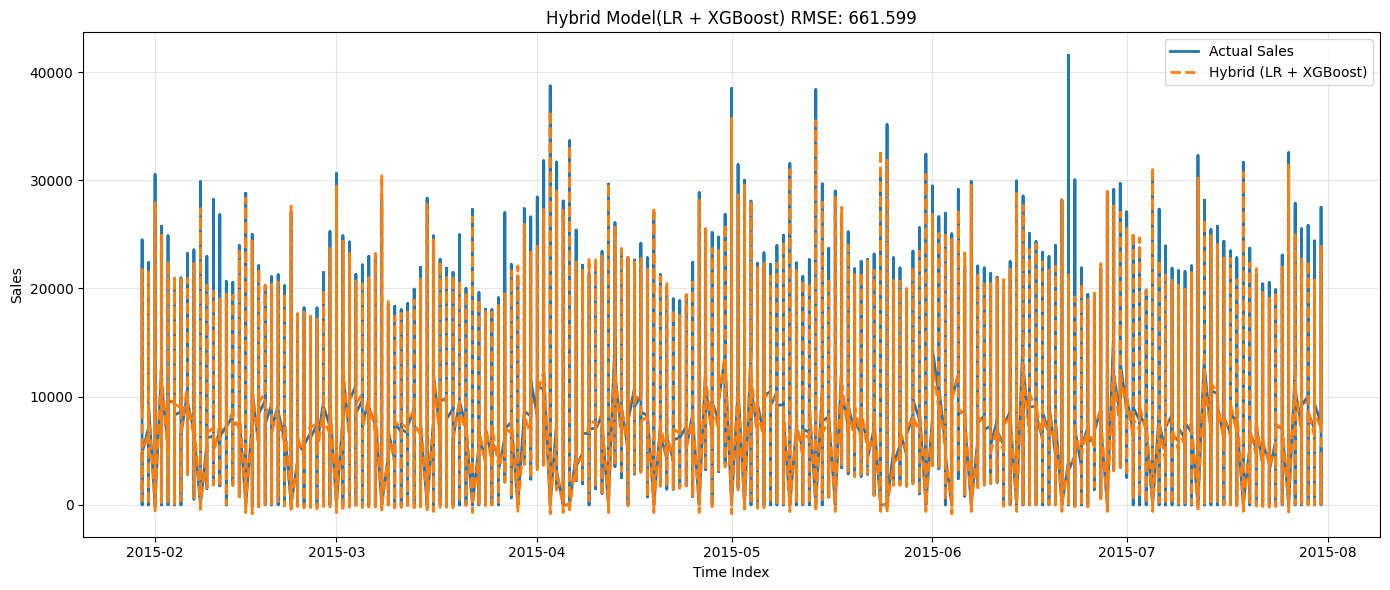

In [25]:
# ===============================================================
# 9. VISUALIZATION
# ===============================================================
visualization_data = pd.DataFrame({
    'date': test.Date,
    'actual_sales': y_test.values,
    'pred_hybrid': hybrid_pred,
})

plt.figure(figsize=(14,6))
plt.plot(visualization_data['date'], visualization_data['actual_sales'], label='Actual Sales', linewidth=2)
plt.plot(visualization_data['date'], visualization_data['pred_hybrid'], label='Hybrid (LR + XGBoost)', linestyle='--', linewidth=2)
plt.title(f"Hybrid Model(LR + XGBoost) RMSE: {rmse_hybrid:.3f}")
plt.xlabel('Time Index')
plt.ylabel('Sales')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()